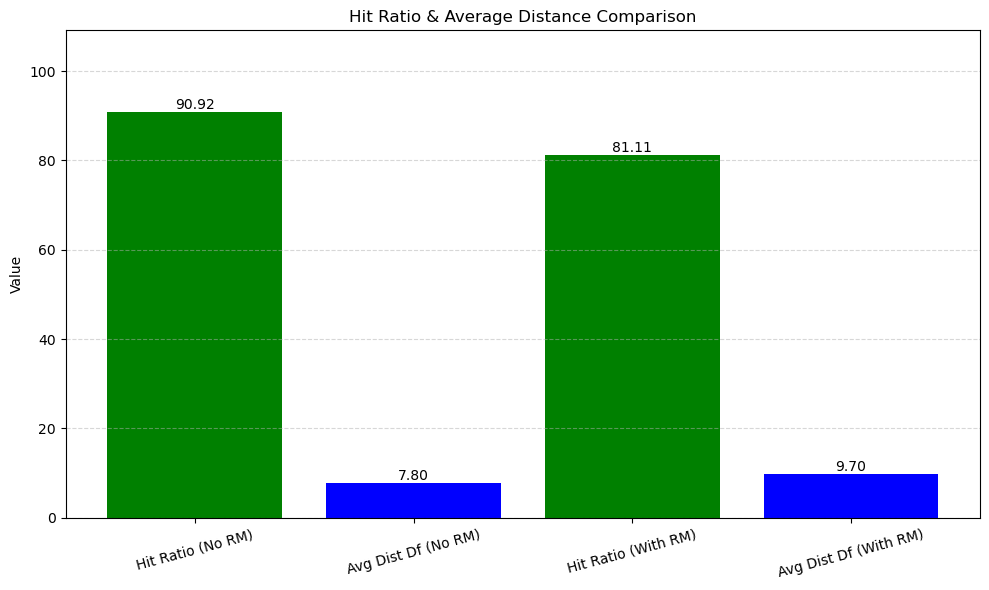

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 이름
files = {
    "No RM": "true_hit_ratio_no_RM.csv",
    "With RM": "true_hit_ratio_w_RM.csv"
}

# 결과 저장용 리스트
labels = []
hit_ratios = []
avg_dists = []

# 파일별 처리
for label, file in files.items():
    df = pd.read_csv(file)
    hit_ratio = df['is_hit'].mean() * 100
    avg_dist = df['dist_df'].mean()

    labels.append(f"Hit Ratio ({label})")
    hit_ratios.append(hit_ratio)

    labels.append(f"Avg Dist Df ({label})")
    avg_dists.append(avg_dist)

# 전체 막대그래프 그리기
values = []
colors = []

for i in range(len(labels)):
    if 'Hit Ratio' in labels[i]:
        values.append(hit_ratios[i // 2])
        colors.append('green')
    else:
        values.append(avg_dists[i // 2])
        colors.append('blue')

# 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)

# 값 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

plt.title('Hit Ratio & Average Distance Comparison')
plt.ylabel('Value')
plt.ylim(0, max(values) * 1.2)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()